# Universal EDA Toolkit
This notebook provides reusable EDA functions for:
- Tabular datasets
- Text datasets
- Image datasets (CSV/pixel)
- Image folder datasets

It is then applied to five real datasets: **Iris**, **Pima Indians Diabetes**, **Loan Prediction**, **SMS Spam Collection**, and a **3,000-row MNIST sample**.

Place the following files in a `data/` folder next to this notebook before running:
`iris.csv`, `diabetes.csv`, `loan.csv`, `spam.csv`, `mnist.csv`.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image


In [2]:
!pip install seaborn


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\Barath J\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
def eda_tabular(csv_path):
    df = pd.read_csv(csv_path)

    print("="*60)
    print("HEAD")
    print(df.head())

    print("\nShape:", df.shape)
    print("\nColumns:", list(df.columns))
    print("\nData Types")
    print(df.dtypes)

    print("\nInfo")
    df.info()

    print("\nSummary")
    print(df.describe(include="all"))

    print("\nMissing Values")
    print(df.isnull().sum())

    sns.heatmap(df.isnull(), cbar=False)
    plt.title("Missing Values")
    plt.show()

    print("\nDuplicates:", df.duplicated().sum())

    # ----------------------------- # Unique Values # ----------------------------- 
    print("\n"+"="*60)
    print("UNIQUE VALUES") 
    print("="*60) 
    for col in df.columns: print(f"{col} : {df[col].nunique()}")

    num_cols = df.select_dtypes(include=np.number).columns
    cat_cols = df.select_dtypes(exclude=np.number).columns

    for c in num_cols:
        plt.figure(figsize=(6,4))
        sns.histplot(df[c].dropna(), kde=True)
        plt.title(c)
        plt.show()

        plt.figure(figsize=(6,2.5))
        sns.boxplot(x=df[c].dropna())
        plt.title(c)
        plt.show()

    for c in cat_cols:
        if df[c].nunique()<=20:
            plt.figure(figsize=(7,4))
            sns.countplot(x=df[c])
            plt.xticks(rotation=45)
            plt.title(c)
            plt.show()

    if len(num_cols)>1:
        plt.figure(figsize=(10,8))
        sns.heatmap(df[num_cols].corr(),annot=True,cmap="coolwarm")
        plt.show()

        if len(num_cols)<=8:
            sns.pairplot(df[num_cols])
            plt.show()

    print("\nSkewness")
    print(df[num_cols].skew())

    print("\nKurtosis")
    print(df[num_cols].kurt())

    print("\nOutliers (IQR)")
    for c in num_cols:
        q1=df[c].quantile(.25)
        q3=df[c].quantile(.75)
        iqr=q3-q1
        low=q1-1.5*iqr
        high=q3+1.5*iqr
        print(c,((df[c]<low)|(df[c]>high)).sum())

In [11]:
def eda_text(csv_path):
    df = pd.read_csv(csv_path, encoding='latin-1')

    print(df.head())
    print(df.shape)
    print(df.dtypes)
    print(df.isnull().sum())
    print("Duplicates:",df.duplicated().sum())

    text_cols=df.select_dtypes(include="object").columns

    print("Text Columns:",list(text_cols))

    for c in text_cols:
        if df[c].nunique()<=20:
            print(df[c].value_counts())
            sns.countplot(x=df[c])
            plt.xticks(rotation=45)
            plt.title(c)
            plt.show()

    for c in text_cols:
        if df[c].nunique()>20:
            temp=df[c].astype(str)
            lengths=temp.apply(len)
            words=temp.apply(lambda x:len(x.split()))

            plt.figure(figsize=(6,4))
            sns.histplot(lengths,bins=30,kde=True)
            plt.title("Character Length")
            plt.show()

            plt.figure(figsize=(6,4))
            sns.histplot(words,bins=30,kde=True)
            plt.title("Word Count")
            plt.show()

            print(lengths.describe())
            print(words.describe())
            break

In [6]:
def eda_image_csv(csv_path):
    df=pd.read_csv(csv_path)

    print(df.head())
    print(df.shape)
    print(df.isnull().sum())

    target=df.columns[0]

    sns.countplot(x=df[target])
    plt.title("Class Distribution")
    plt.show()

    size=int((df.shape[1]-1)**0.5)

    plt.figure(figsize=(8,8))
    for i in range(min(9,len(df))):
        plt.subplot(3,3,i+1)
        img=df.iloc[i,1:].values.reshape(size,size)
        plt.imshow(img,cmap="gray")
        plt.title(df.iloc[i,0])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

    pixels=df.iloc[:,1:]
    print("Pixel Mean:",pixels.mean().mean())
    print("Pixel Std:",pixels.std().mean())

    sns.histplot(pixels.values.flatten(),bins=50)
    plt.title("Pixel Distribution")
    plt.show()


def eda_image_folder(folder_path):
    classes=[c for c in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path,c))]
    print("Classes:",classes)

    for c in classes:
        print(c,":",len(os.listdir(os.path.join(folder_path,c))),"images")

    plt.figure(figsize=(12,6))
    for i,c in enumerate(classes[:6]):
        folder=os.path.join(folder_path,c)
        img=Image.open(os.path.join(folder,os.listdir(folder)[0]))
        plt.subplot(2,3,i+1)
        plt.imshow(img)
        plt.title(c)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

## Example Usage -- Applied to Real Datasets

### 1. Iris Dataset (Tabular)

HEAD
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Shape: (150, 5)

Columns: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']

Data Types
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object

Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 

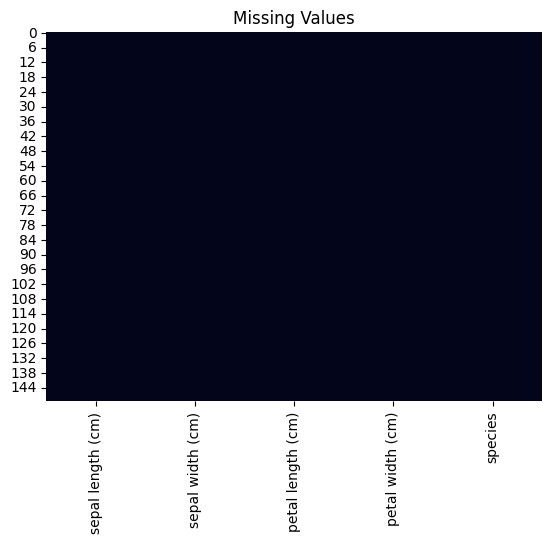


Duplicates: 1

UNIQUE VALUES
sepal length (cm) : 35
sepal width (cm) : 23
petal length (cm) : 43
petal width (cm) : 22
species : 3


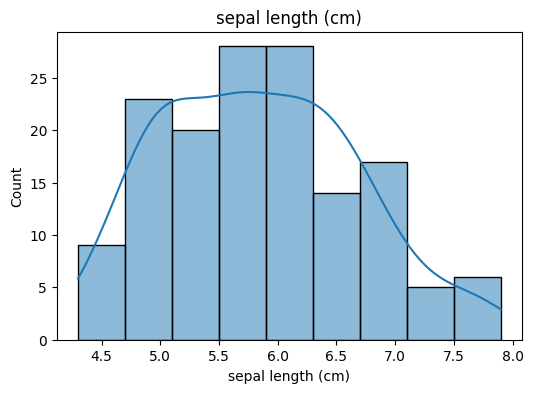

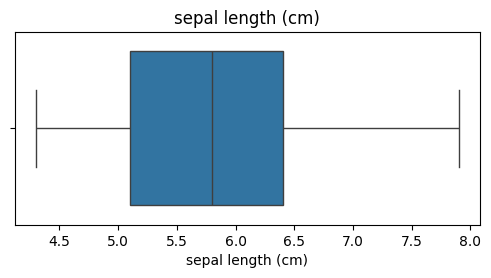

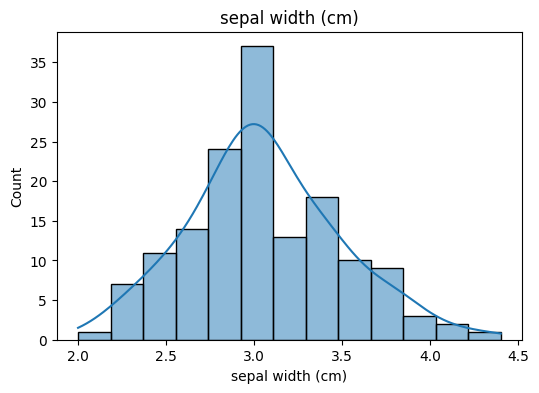

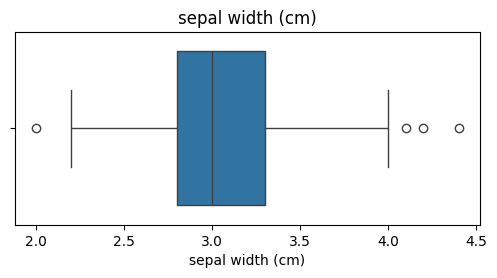

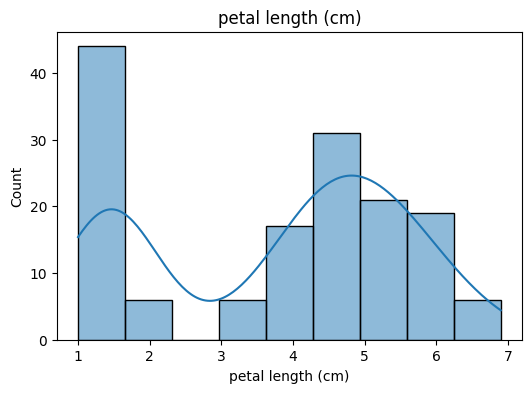

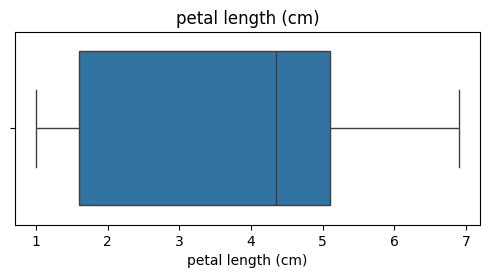

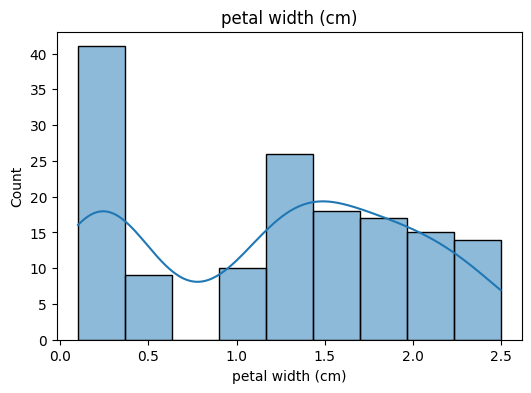

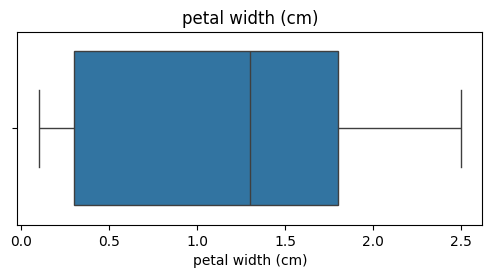

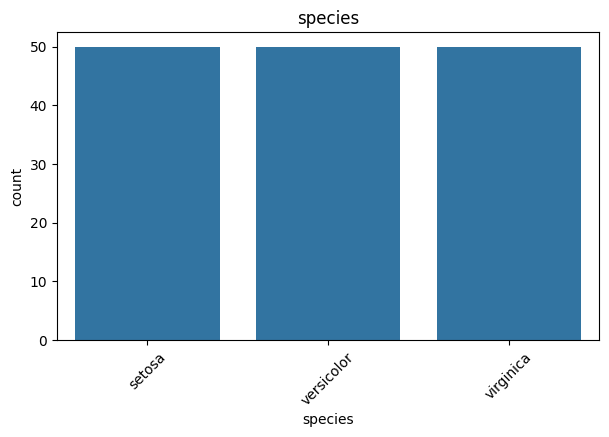

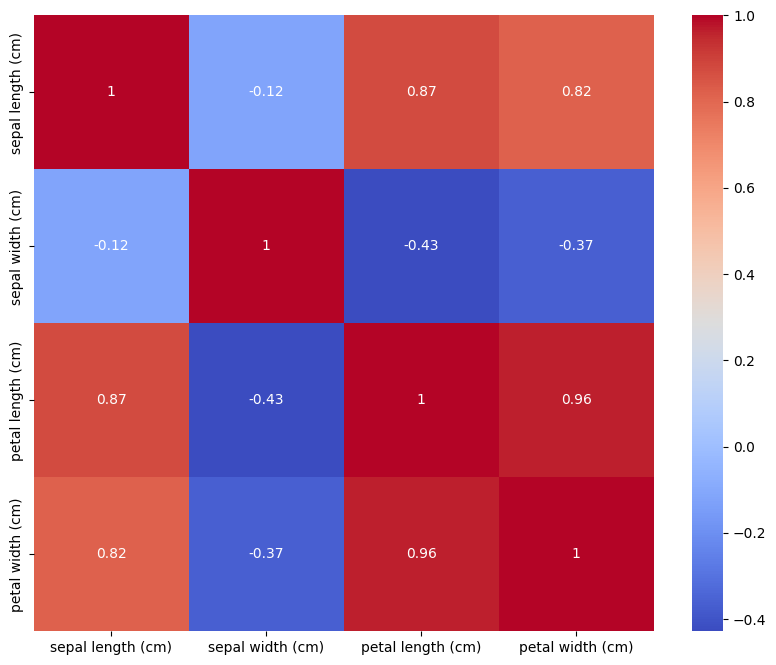

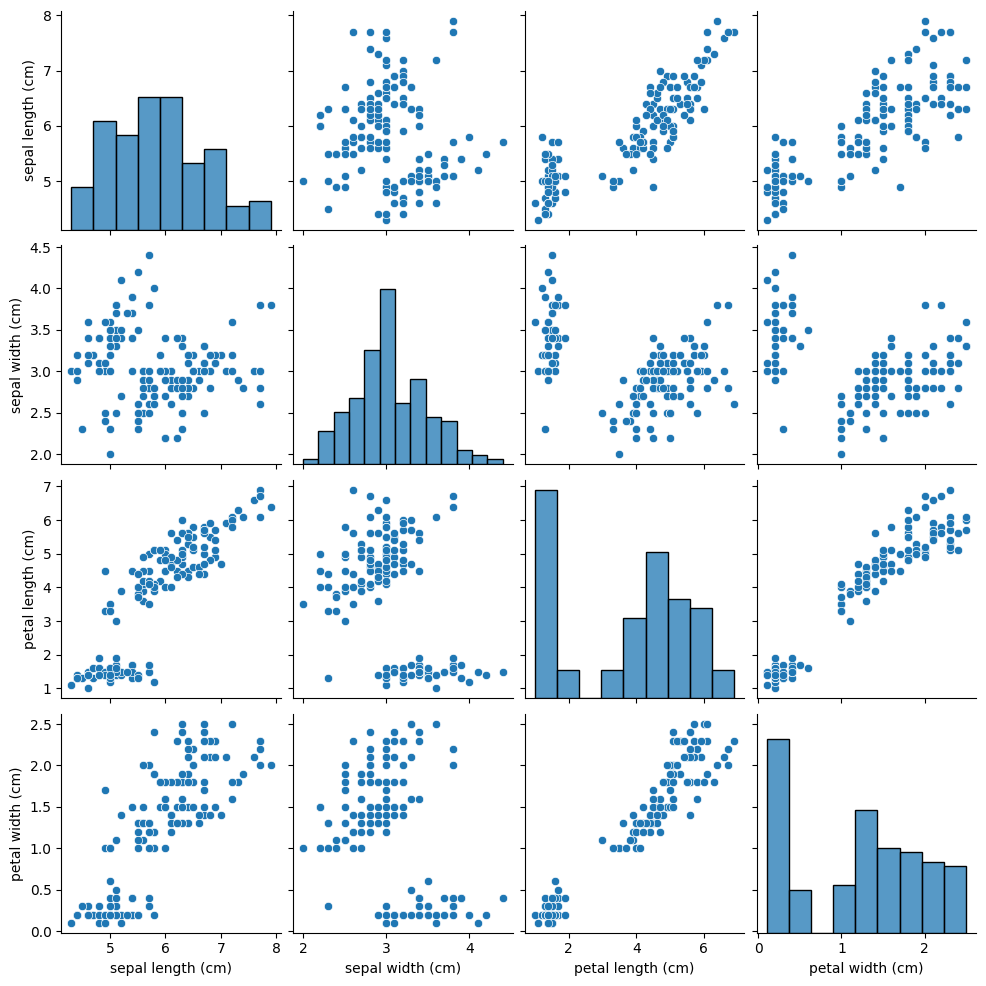


Skewness
sepal length (cm)    0.314911
sepal width (cm)     0.318966
petal length (cm)   -0.274884
petal width (cm)    -0.102967
dtype: float64

Kurtosis
sepal length (cm)   -0.552064
sepal width (cm)     0.228249
petal length (cm)   -1.402103
petal width (cm)    -1.340604
dtype: float64

Outliers (IQR)
sepal length (cm) 0
sepal width (cm) 4
petal length (cm) 0
petal width (cm) 0


In [7]:
eda_tabular("data/iris.csv")

### 2. Pima Indians Diabetes Dataset (Tabular)

HEAD
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Shape: (768, 9)

Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data Types
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness             

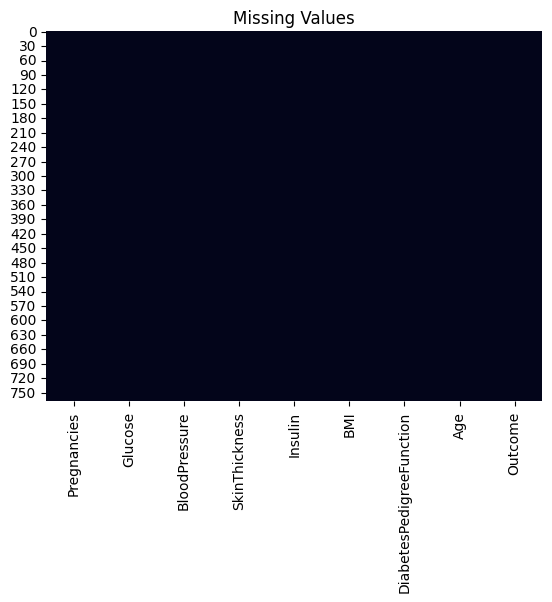


Duplicates: 0

UNIQUE VALUES
Pregnancies : 17
Glucose : 136
BloodPressure : 47
SkinThickness : 51
Insulin : 186
BMI : 248
DiabetesPedigreeFunction : 517
Age : 52
Outcome : 2


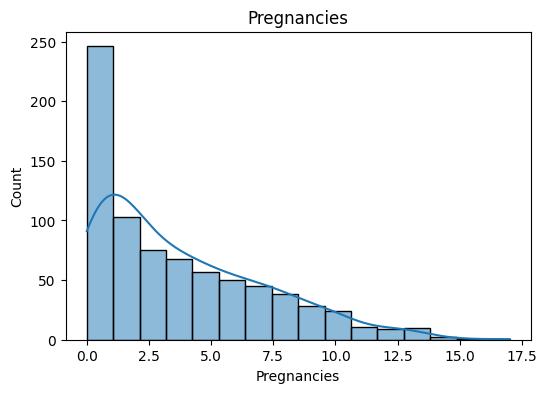

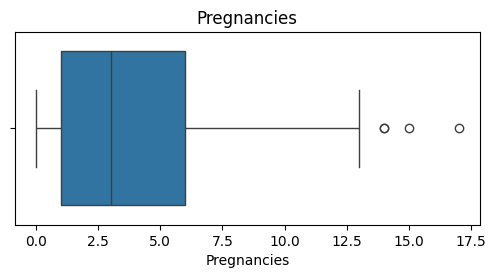

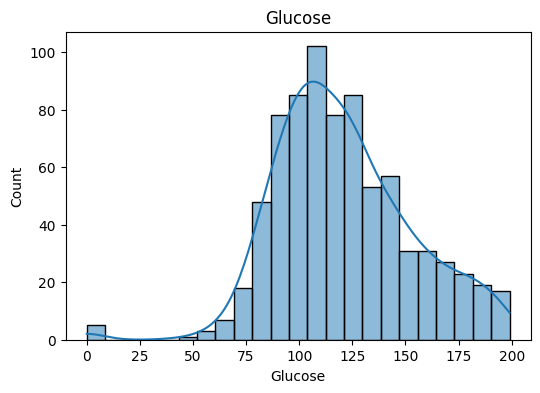

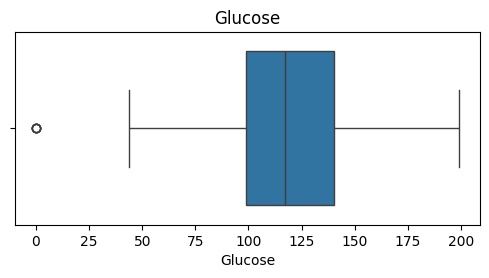

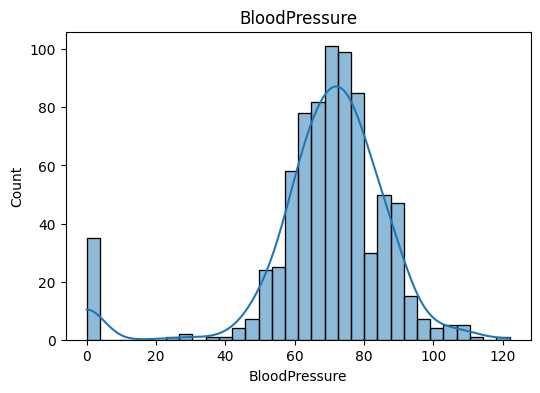

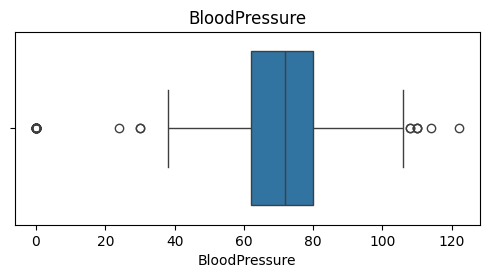

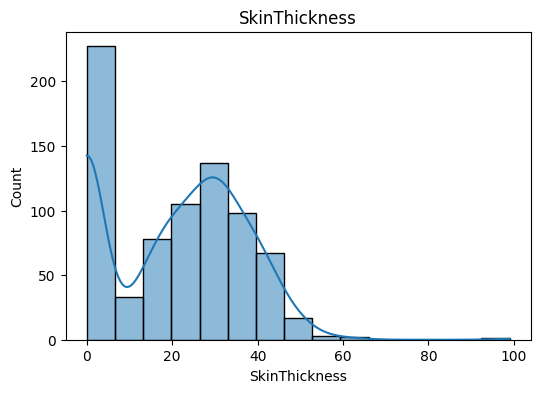

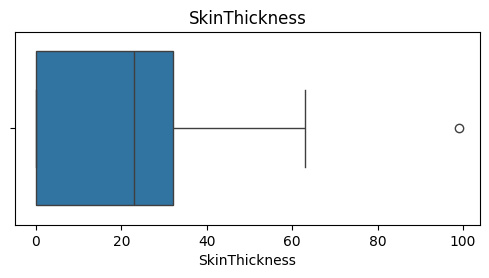

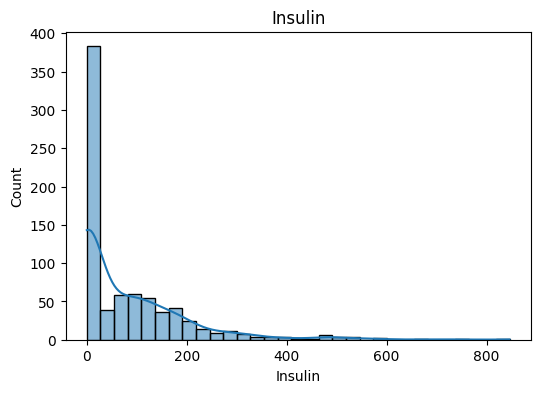

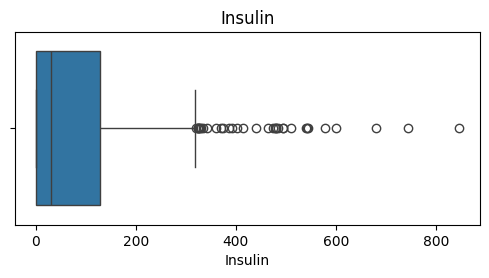

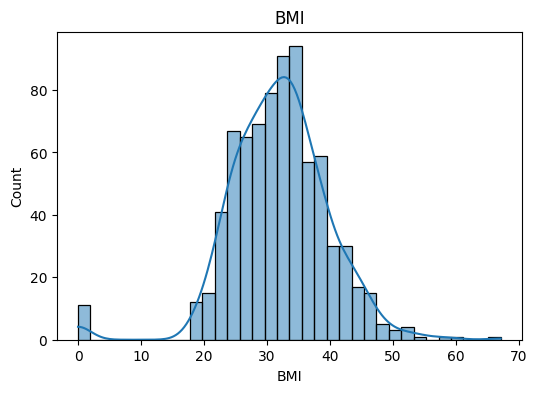

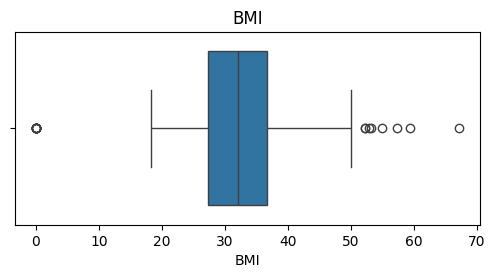

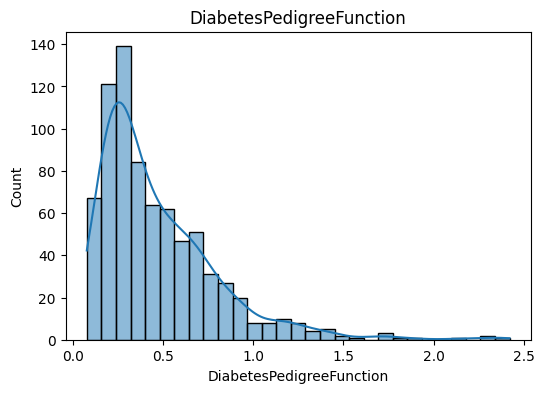

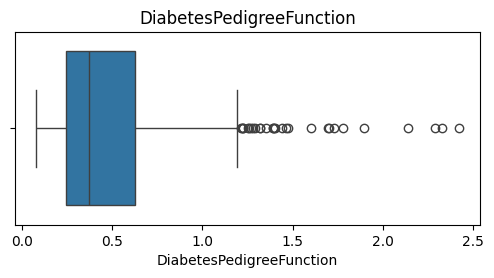

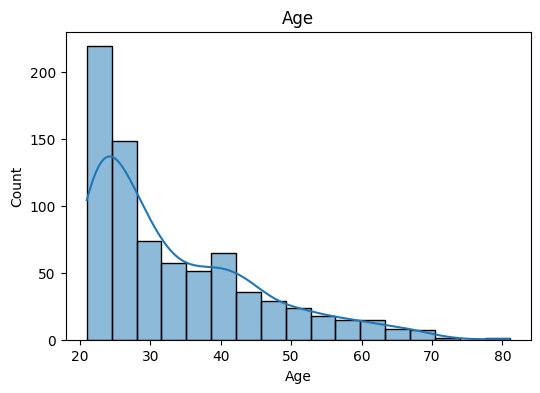

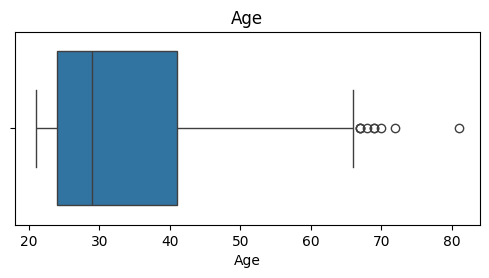

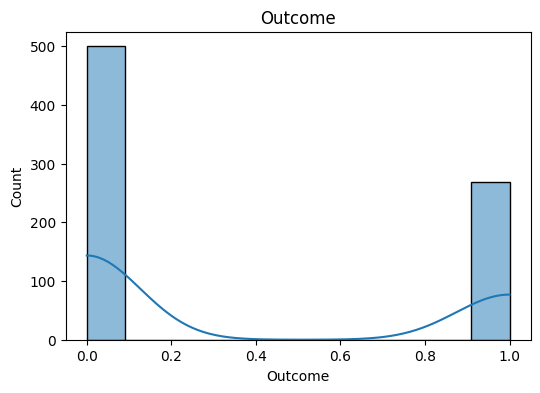

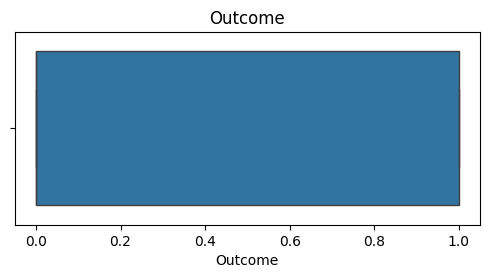

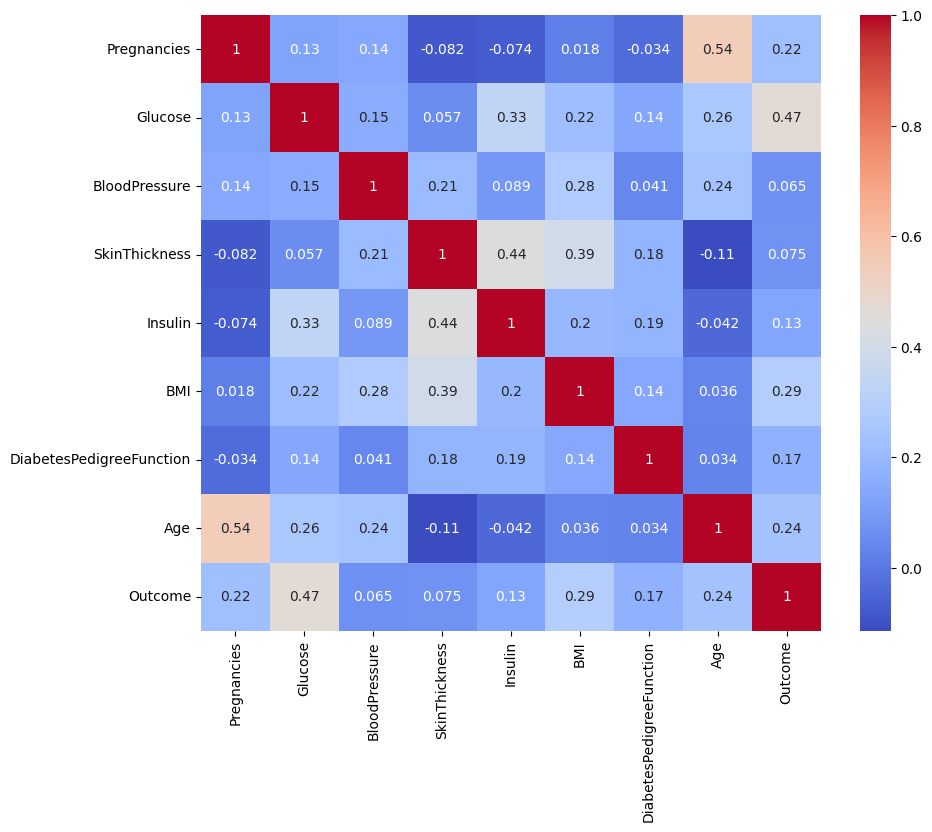


Skewness
Pregnancies                 0.901674
Glucose                     0.173754
BloodPressure              -1.843608
SkinThickness               0.109372
Insulin                     2.272251
BMI                        -0.428982
DiabetesPedigreeFunction    1.919911
Age                         1.129597
Outcome                     0.635017
dtype: float64

Kurtosis
Pregnancies                 0.159220
Glucose                     0.640780
BloodPressure               5.180157
SkinThickness              -0.520072
Insulin                     7.214260
BMI                         3.290443
DiabetesPedigreeFunction    5.594954
Age                         0.643159
Outcome                    -1.600930
dtype: float64

Outliers (IQR)
Pregnancies 4
Glucose 5
BloodPressure 45
SkinThickness 1
Insulin 34
BMI 19
DiabetesPedigreeFunction 29
Age 9
Outcome 0


In [8]:
eda_tabular("data/diabetes.csv")

### 3. Loan Prediction Dataset (Tabular, mixed types)

HEAD
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1

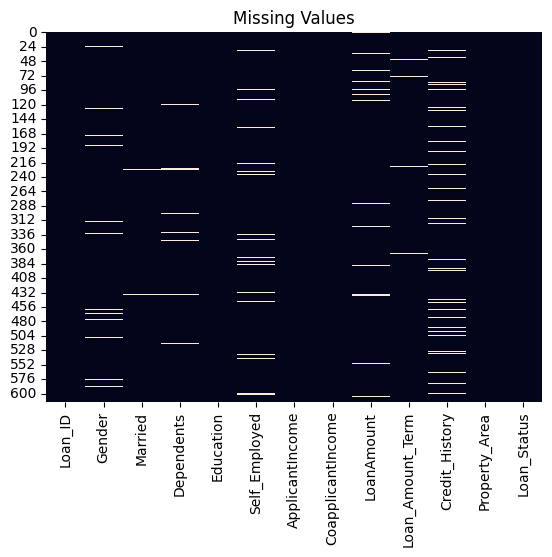


Duplicates: 0

UNIQUE VALUES
Loan_ID : 614
Gender : 2
Married : 2
Dependents : 4
Education : 2
Self_Employed : 2
ApplicantIncome : 505
CoapplicantIncome : 287
LoanAmount : 203
Loan_Amount_Term : 10
Credit_History : 2
Property_Area : 3
Loan_Status : 2


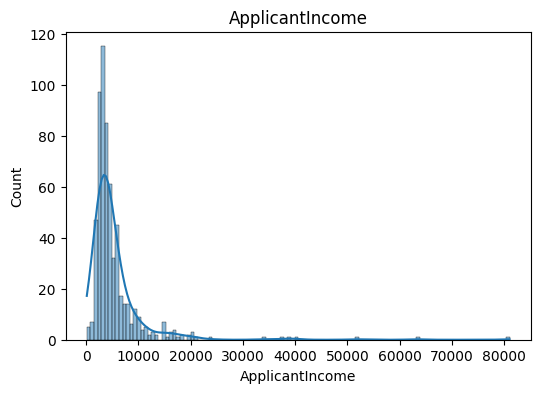

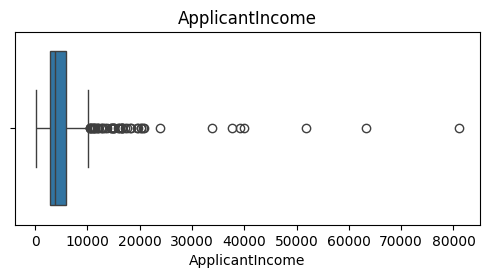

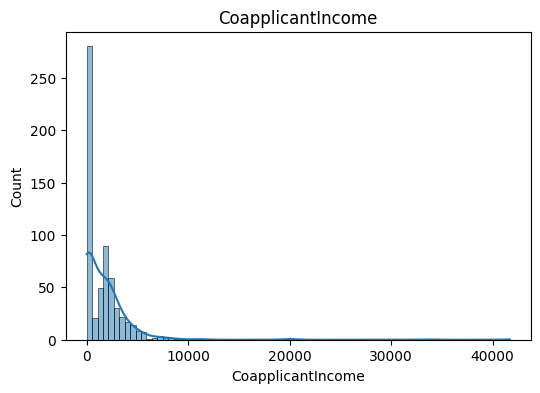

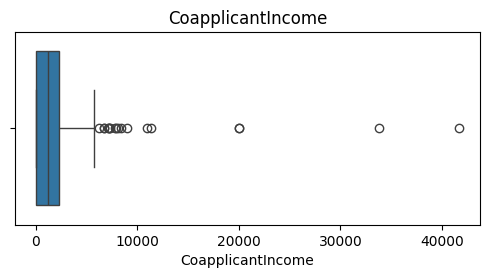

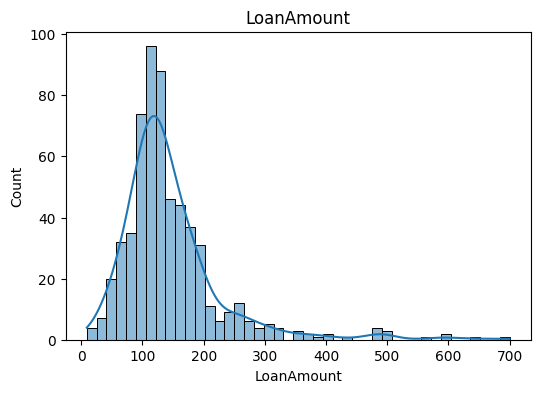

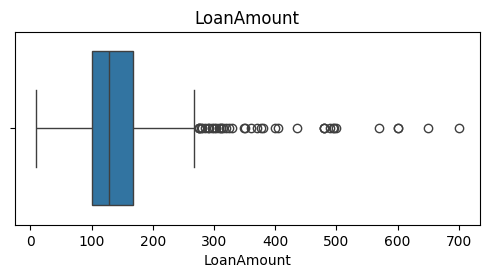

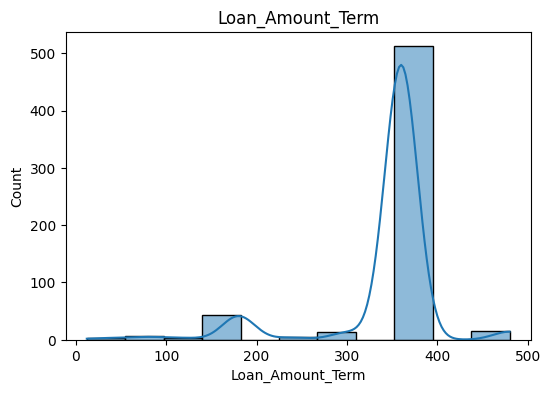

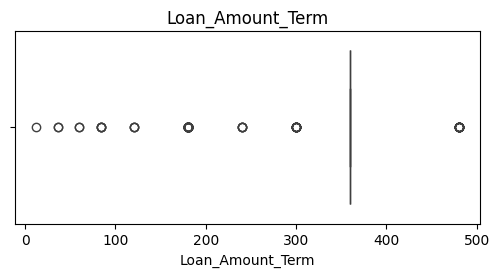

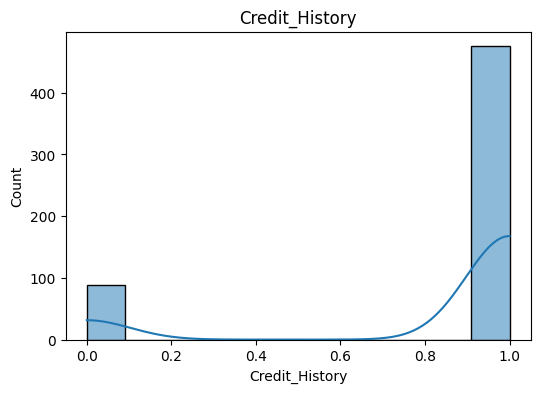

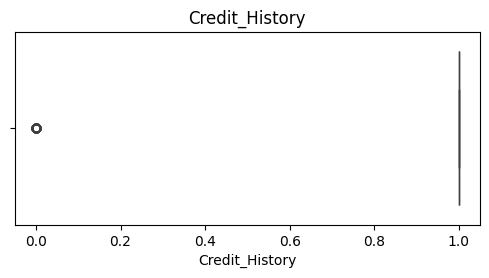

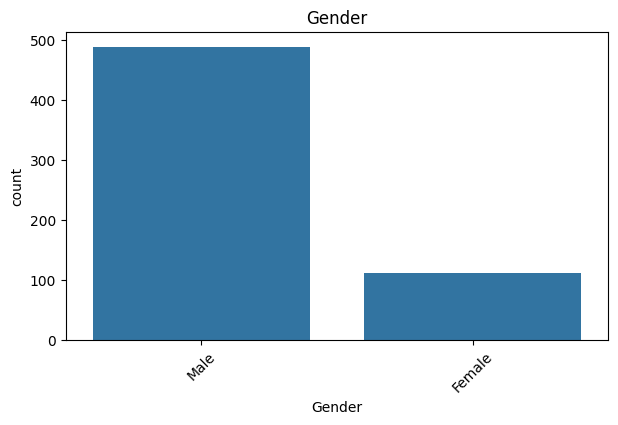

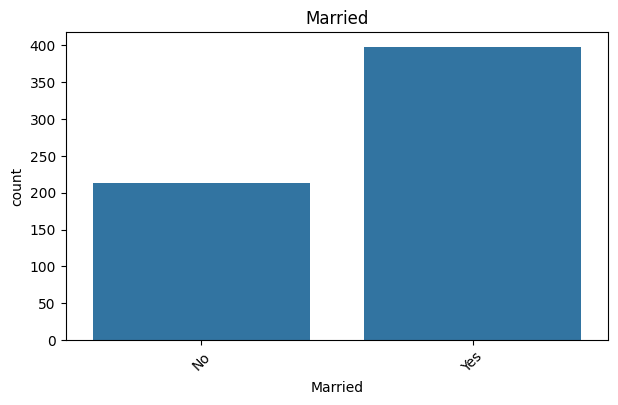

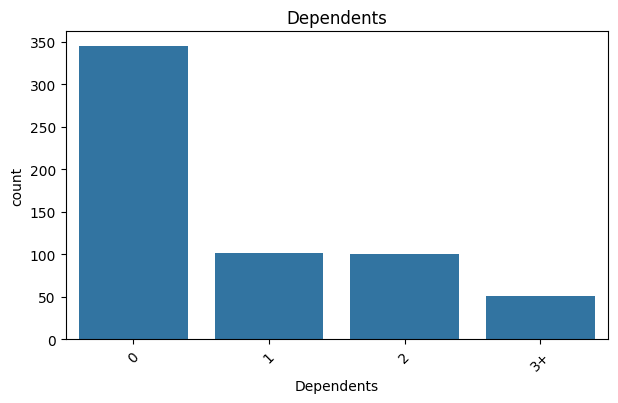

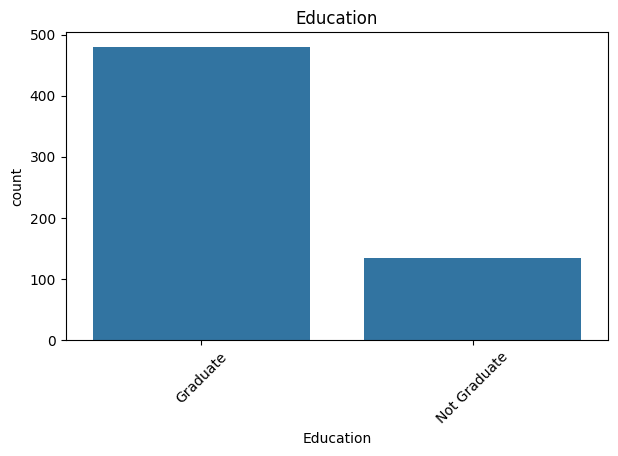

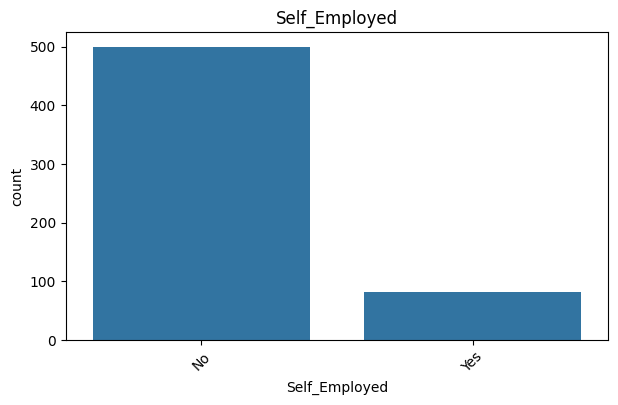

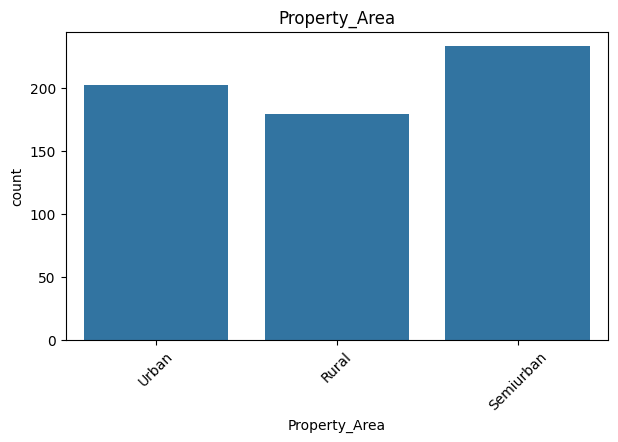

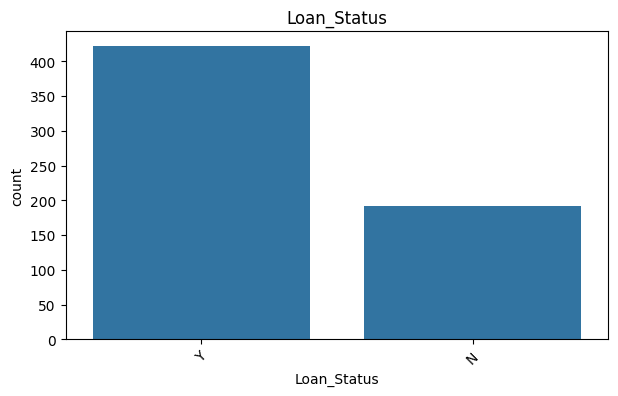

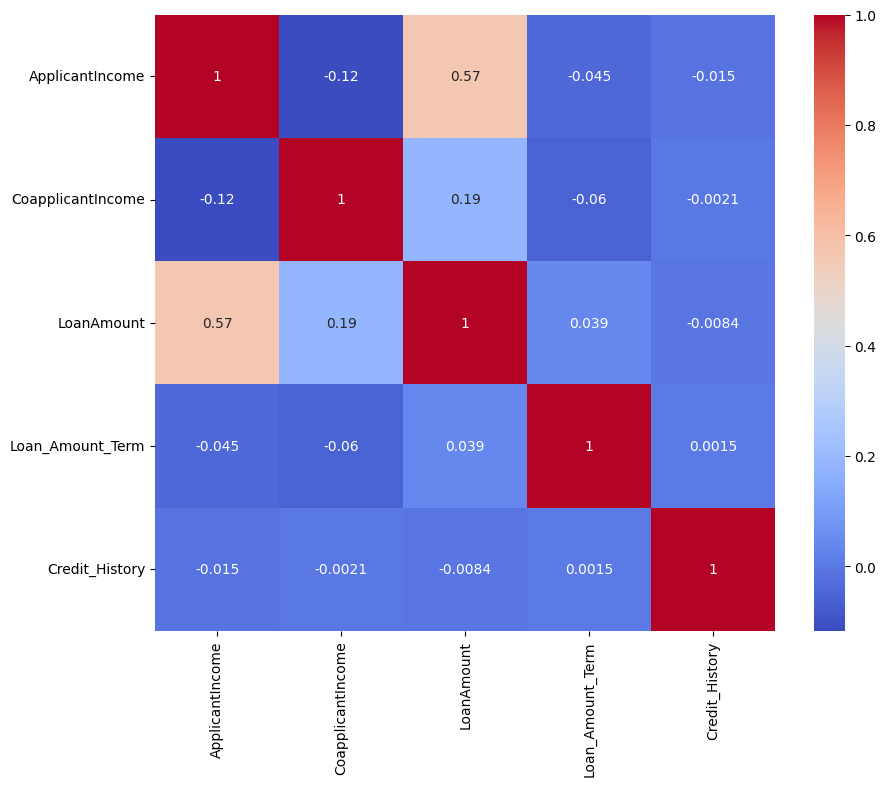

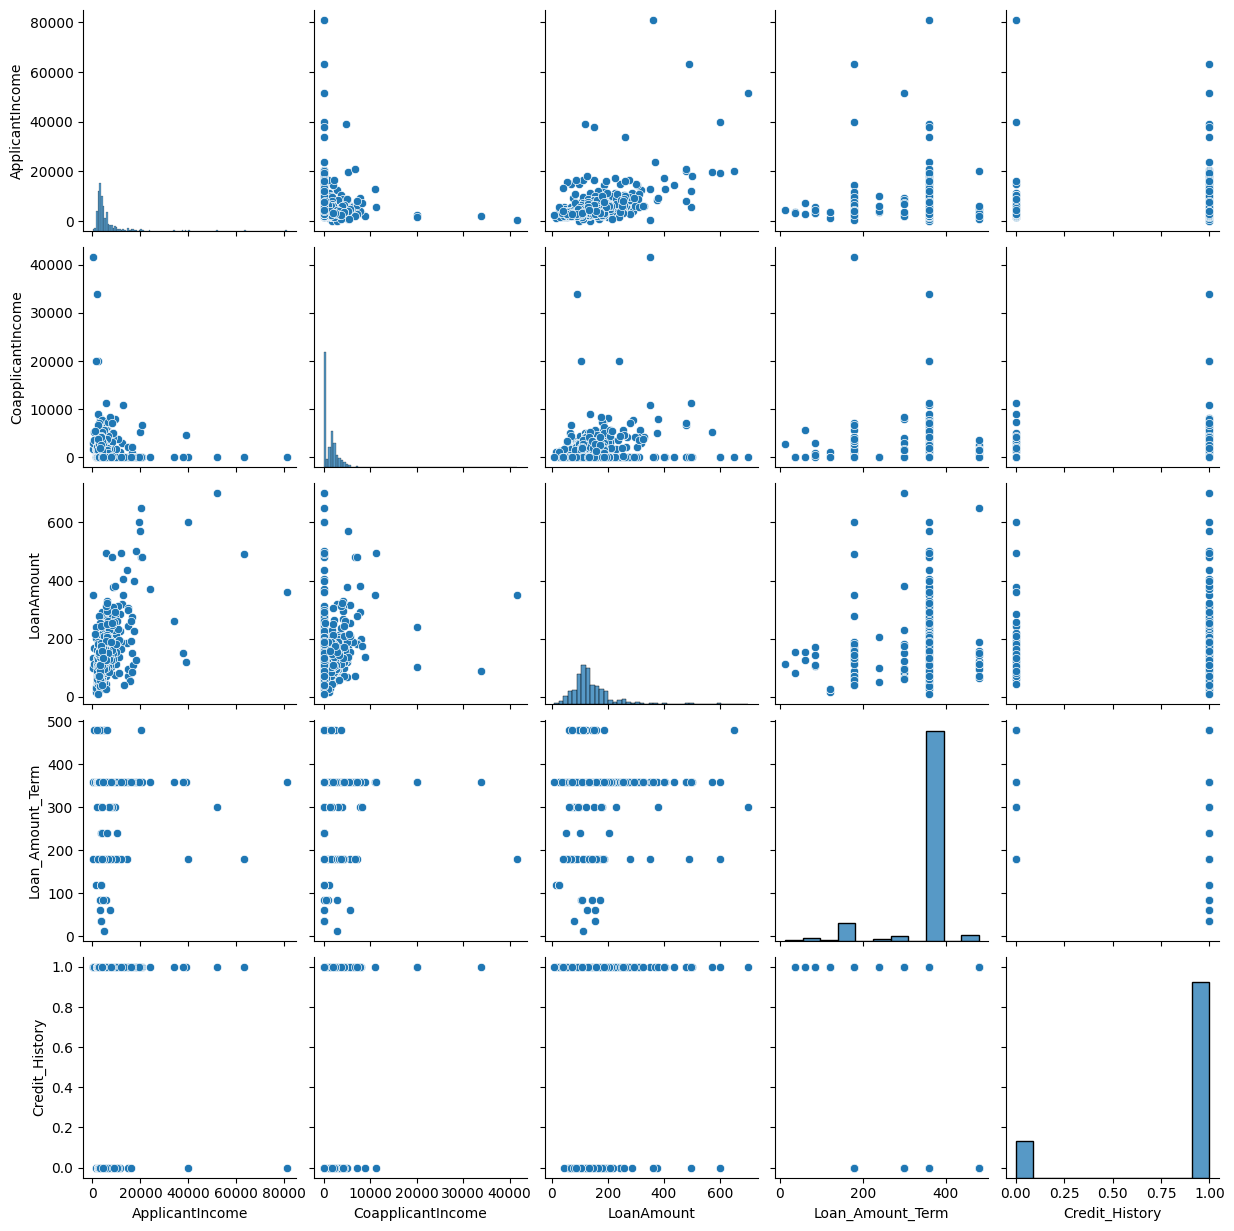


Skewness
ApplicantIncome      6.539513
CoapplicantIncome    7.491531
LoanAmount           2.677552
Loan_Amount_Term    -2.362414
Credit_History      -1.882361
dtype: float64

Kurtosis
ApplicantIncome      60.540676
CoapplicantIncome    84.956384
LoanAmount           10.401533
Loan_Amount_Term      6.673474
Credit_History        1.548763
dtype: float64

Outliers (IQR)
ApplicantIncome 50
CoapplicantIncome 18
LoanAmount 39
Loan_Amount_Term 88
Credit_History 89


In [9]:
eda_tabular("data/loan.csv")

### 4. SMS Spam Collection Dataset (Text)

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  
(5572, 5)
v1            object
v2            object
Unnamed: 2    object
Unnamed: 3    object
Unnamed: 4    object
dtype: object
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64
Duplicates: 403
Text Columns: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']
v1
ham     4825
spam     747
Name: count, dtype: int64


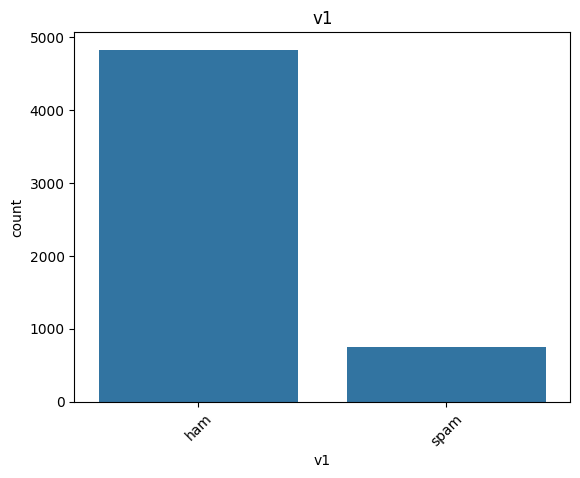

Unnamed: 3
 MK17 92H. 450Ppw 16"                         2
GE                                            2
 why to miss them                             1
U NO THECD ISV.IMPORTANT TOME 4 2MORO\""      1
i wil tolerat.bcs ur my someone..... But      1
 ILLSPEAK 2 U2MORO WEN IM NOT ASLEEP...\""    1
whoever is the KING\"!... Gud nyt"            1
 TX 4 FONIN HON                               1
 \"OH No! COMPETITION\". Who knew             1
IåÕL CALL U\""                                1
Name: count, dtype: int64


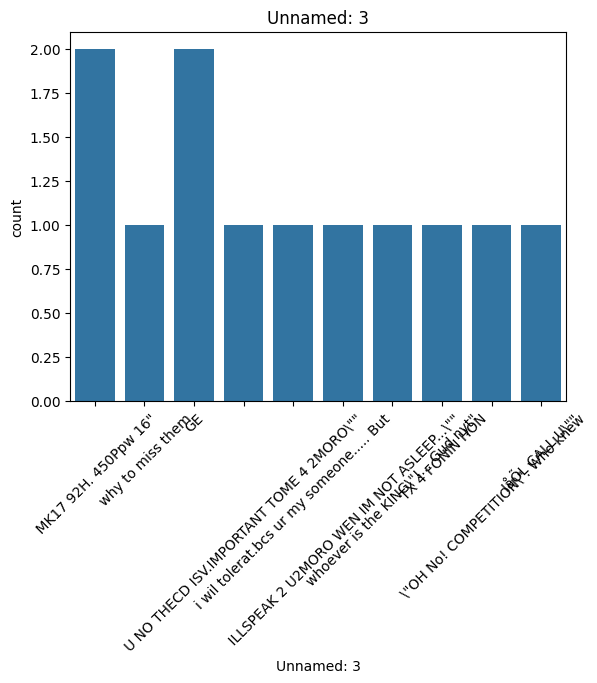

Unnamed: 4
GNT:-)"                                                     2
 just Keep-in-touch\" gdeve.."                              1
 Never comfort me with a lie\" gud ni8 and sweet dreams"    1
 CALL 2MWEN IM BK FRMCLOUD 9! J X\""                        1
 one day these two will become FREINDS FOREVER!"            1
Name: count, dtype: int64


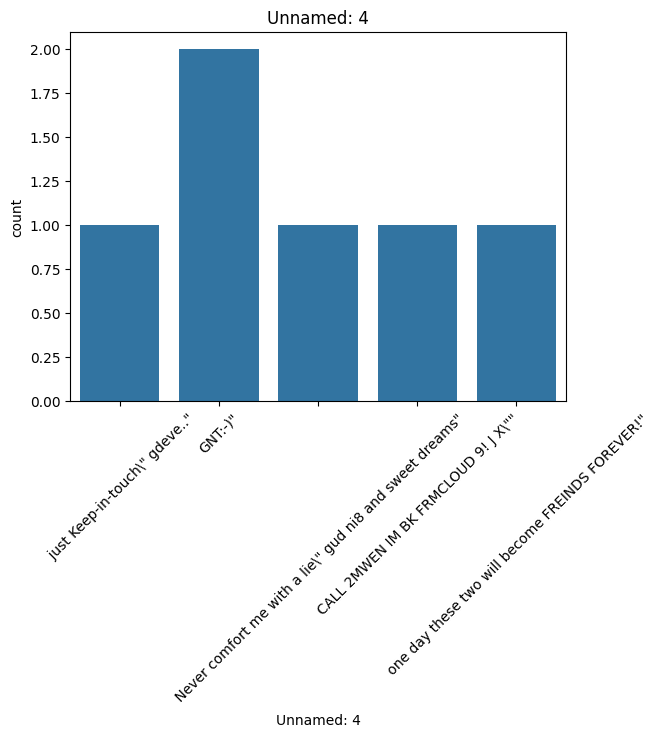

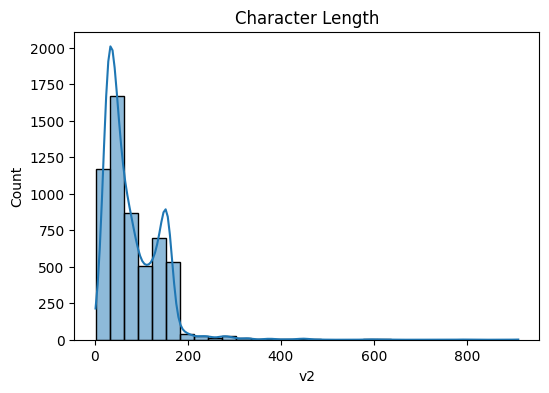

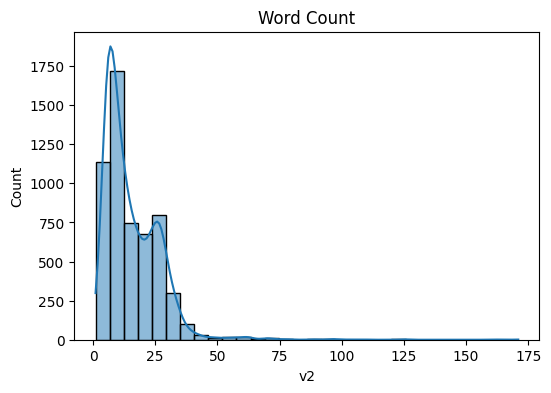

count    5572.000000
mean       80.118808
std        59.690841
min         2.000000
25%        36.000000
50%        61.000000
75%       121.000000
max       910.000000
Name: v2, dtype: float64
count    5572.000000
mean       15.494436
std        11.329427
min         1.000000
25%         7.000000
50%        12.000000
75%        23.000000
max       171.000000
Name: v2, dtype: float64


In [12]:
eda_text("data/spam.csv")

### 5. MNIST Sample Dataset (Image CSV)

   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      6       0       0       0       0       0       0       0       0   
1      5       0       0       0       0       0       0       0       0   
2      7       0       0       0       0       0       0       0       0   
3      9       0       0       0       0       0       0       0       0   
4      5       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0         0         

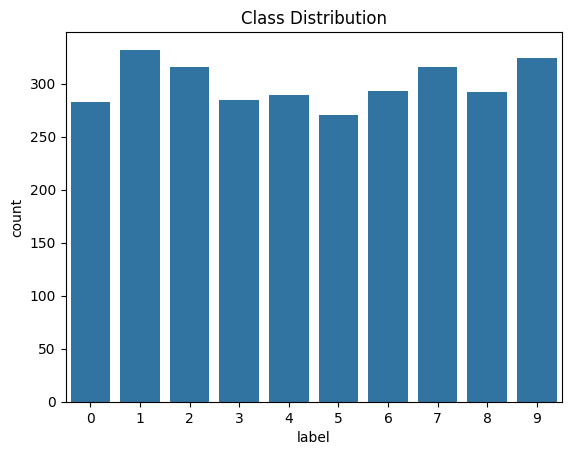

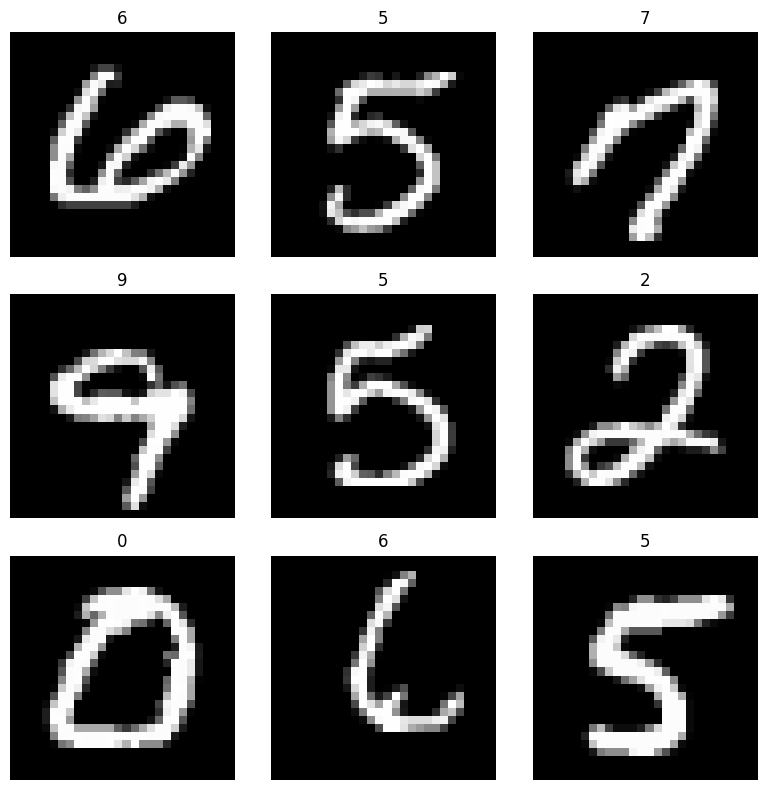

Pixel Mean: 33.171526785714285
Pixel Std: 49.10731120903804


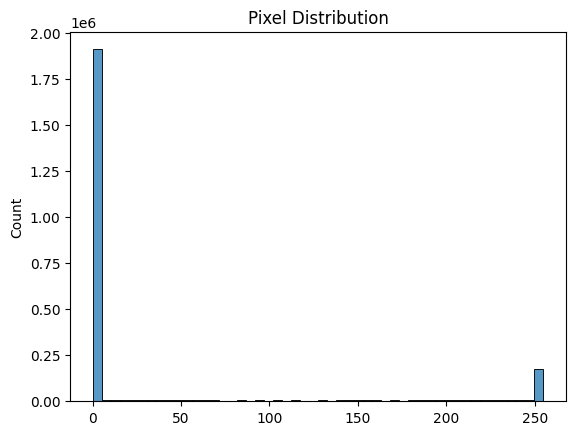

In [13]:
eda_image_csv("data/mnist.csv")